**Lasso Regression**

While Ridge (L2) shrinks coefficients close to zero, Lasso (L1) has a "superpower": it can shrink coefficients exactly to zero. This effectively performs feature selection, meaning the model decides which columns are useless and removes them for you.

Lasso adds a penalty equal to the absolute value of the magnitude of coefficients.

$$J(w) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{m} |w_j|$$

The L1 penalty shape is a diamond (square rotated 45°). When the optimization process hits the "corners" of this diamond, the coefficient for that axis becomes zero. This is why Lasso is used for Sparse Models—it leaves you with only the most important features.

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

diabetes = datasets.load_diabetes()
X, y = diabetes.data, diabetes.target.reshape(-1, 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def soft_threshold(rho, lamda):
    """Soft thresholding operator for L1 penalty"""
    if rho < -lamda:
        return rho + lamda
    elif rho > lamda:
        return rho - lamda
    else:
        return 0

def manual_lasso_fit(X, y, alpha, iterations=100):
    m, n = X.shape
    weights = np.zeros((n, 1))
    bias = np.mean(y)
    
    for _ in range(iterations):
        for j in range(n):
            X_j = np.delete(X, j, axis=1)
            w_j = np.delete(weights, j, axis=0)
            y_pred = np.dot(X_j, w_j) + bias
            
            rho_j = np.dot(X[:, j], (y - y_pred))
            
            weights[j] = soft_threshold(rho_j, alpha * m) / np.sum(X[:, j]**2)
            
    return bias, weights.flatten()

alpha_val = 1.0
m_bias, m_coeffs = manual_lasso_fit(X_scaled, y, alpha=alpha_val)

sk_lasso = Lasso(alpha=alpha_val)
sk_lasso.fit(X_scaled, y)

print(f"Manual Intercept: {m_bias:.4f} | Sklearn: {sk_lasso.intercept_[0]:.4f}")
print(f"Coefficients match? {np.allclose(m_coeffs, sk_lasso.coef_, atol=1e-2)}")

Manual Intercept: 152.1335 | Sklearn: 152.1335
Coefficients match? True


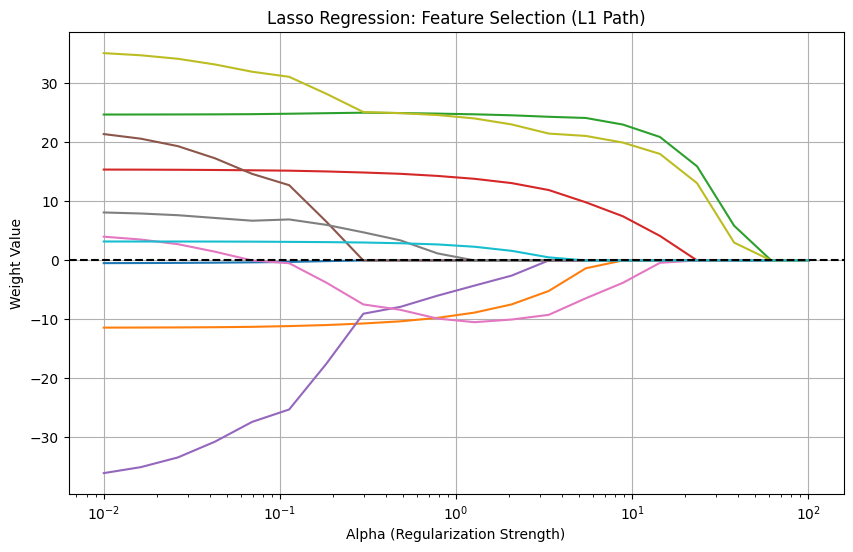

In [3]:
alphas = np.logspace(-2, 2, 20)
coef_history = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_scaled, y)
    coef_history.append(model.coef_)

plt.figure(figsize=(10, 6))
plt.plot(alphas, coef_history)
plt.xscale('log')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Weight Value')
plt.title('Lasso Regression: Feature Selection (L1 Path)')
plt.grid(True)
plt.show()